In [4]:
import random
import numpy as np
from IPython.display import clear_output

class Ship:
    def __init__(self, size: int) -> None:
        self.size: int = size
        self.position_unhit: set[tuple[int, int]] = set()
        self.position_hit: set[tuple[int, int]] = set()

        self.hits: int = 0
        self.sunk: bool = False

    def place(self, positions: list[tuple[int, int]]) -> None:
        self.position_unhit = set(positions)

    def register_hit(self, position: tuple[int, int]) -> bool:
        # return True if hit, False if miss
        
        if position not in self.position_unhit:
            return False

        self.position_unhit.remove(position)
        self.position_hit.add(position)
        self.hits += 1
        if self.hits == self.size:
            self.sunk = True
        return True    

class Board:
    def __init__(self) -> None:
        self.grid: np.ndarray = np.array([[' '] * 10 for _ in range(10)])
        self.ships: list[Ship] = [Ship(size) for size in [5, 4, 3, 3, 2]]

        self.turns: int = 0
        
    def print_board(self) -> None:
        print("  " + " ".join(str(i) for i in range(10)))
        for i in range(10):
            print(f"{i} " + " ".join(self.grid[i]))

    def set_ships(self, *positions: list[list[tuple[int, int]]]) -> None:
        # If positions are provided, set ships to the positions
        if positions != ():
            for ship, pos in zip(self.ships, positions):
                ship.place(pos)
            return 
        
        # randomise ship placement if no positions provided
        all_positions = set()

        for ship in self.ships:
            while True:

                orientation = random.choice(['horizontal', 'vertical'])
                if orientation == 'horizontal':
                    row = random.randint(0, 9)
                    col = random.randint(0, 10 - ship.size)
                    ship.position_unhit = {(row, col + i) for i in range(ship.size)}
                else:
                    row = random.randint(0, 10 - ship.size)
                    col = random.randint(0, 9)
                    ship.position_unhit = {(row + i, col) for i in range(ship.size)}
                
                # Check for overlap
                if not all_positions.intersection(ship.position_unhit):
                    all_positions.update(ship.position_unhit)
                    break

    def receive_attack(self, position: tuple[int, int]) -> None:
        for ship in self.ships: 
            if ship.register_hit(position):
                self.grid[position[0], position[1]] = 'X'  # Mark hit

                # Check if the ship is sunk
                if ship.sunk:
                    for i, j in ship.position_hit:
                        self.grid[i, j] = 'S'  # Mark sunk
                return 
            
        self.grid[position[0], position[1]] = 'O'  # Mark miss
        return

    def play(self) -> None:
        self.set_ships()
        #* place ships in fixed positions at top left corner for testing purposes
        # self.set_ships(
        #     [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4)],
        #     [(1, 0), (1, 1), (1, 2), (1, 3)],
        #     [(2, 0), (2, 1), (2, 2)],
        #     [(3, 0), (3, 1), (3, 2)],
        #     [(4, 0), (4, 1)]
        # )

        self.print_board()

        while True:
            row, col = list(input("rc: "))
            row = int(row)
            col = int(col)

            self.receive_attack((row, col))
            self.turns += 1

            # print board
            clear_output(wait=True)

            self.print_board()
            print()
            print(f"Row: {row}")
            print(f"Col: {col}")
            print(f"Number of Turns: {self.turns}")
            
            if all(ship.sunk for ship in self.ships):
                print("Win")
                break

# test code
board = Board()
board.play()

  0 1 2 3 4 5 6 7 8 9
0                    
1                    
2                    
3                    
4                    
5                    
6                    
7                    
8                    
9                    


ValueError: not enough values to unpack (expected 2, got 0)

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

#* decorator to display heat map using seaborn (for testing purposes)
def display_heat_map(func):
    def wrapper(*args, **kwargs) -> tuple[int, int, any]:
        row, col, heat_map = func(*args, **kwargs, return_heat_map=True)

        sns.heatmap(heat_map, cmap=plt.get_cmap("Blues"), annot=True, linewidths=0.5)

        print((row, col))

    return wrapper

(np.int64(4), np.int64(5))


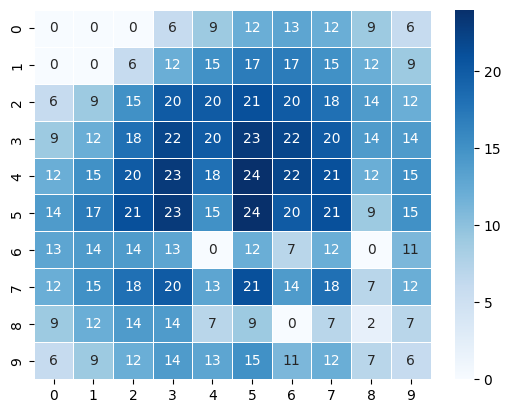

In [10]:
# generate next move using heat map algorithm

@display_heat_map
def generate_next_move(board: np.ndarray, ship_sunk_state: list[bool], return_heat_map: bool = False) -> tuple[int, int, any]:

    #* bool test_mode is used to determine whether to return heat map to display using decorator

    heat_map = np.array([[0] * 10 for _ in range(10)])

    # generate heat map based on all possible ship placements
    if 'X' not in board:
        for ship_size, sunk in zip([5, 4, 3, 3, 2], ship_sunk_state):

            # check if ship is already sunk
            if sunk:
                continue

            # place horizontally
            for i in range(10):
                for j in range(10 - ship_size + 1):

                    # skip if ship placement is not possible
                    if set(board[i, j:j + ship_size].ravel()) != {' '}:
                        continue

                    heat_map[i, j:j + ship_size] += 1

            # place vertically
            for i in range(10 - ship_size + 1):
                for j in range(10):

                    # skip if ship placement is not possible
                    if set(board[i:i + ship_size, j].ravel()) != {' '}:
                        continue
                    
                    heat_map[i:i + ship_size, j] += 1

    else:
        
        # target around hit locations
        for ship_size, sunk in zip([5, 4, 3, 3, 2], ship_sunk_state):

            # check if ship is already sunk
            if sunk:
                continue

            #* for each direction, check if ship can be placed. Prioritise a direction if there are multiple hits in a line in the same direction
            #*
            #* i.e.
            #* [ ,  ,  , ]
            #* [ , X, X, ]  --->    Horizontal search will be prioritised since there are multiple hits in a horizontal line
            #* [ ,  ,  , ]
            #*
            #* priority will be determined by number of hits for a possible ship placement by the following values:
            #*
            #*  hits | heat map value
            #* ------|----------------
            #*    1  |      1
            #*    2  |     10
            #*    3  |     20
            #*    4  |     30

            priority_values = [0, 1, 10, 20, 30]
                      
            # check all possible horizontal placements if it coincides with hit locations
            for i in range(10):
                for j in range(10 - ship_size + 1):

                    # skip if ship placement is not possible or does not coincide with hit locations
                    if set(board[i, j:j + ship_size].ravel()) != {' ', 'X'}:
                        continue

                    heat_map[i, j:j + ship_size][board[i, j:j + ship_size] == ' '] += priority_values[np.count_nonzero(board[i, j:j + ship_size] == 'X')]

            # check all possible vertical placements if it coincides with hit locations
            for i in range(10 - ship_size + 1):
                for j in range(10):

                    # skip if ship placement is not possible or does not coincide with hit locations
                    if set(board[i:i + ship_size, j].ravel()) != {' ', 'X'}:
                        continue

                    heat_map[i:i + ship_size, j][board[i:i + ship_size, j] == ' '] += priority_values[np.count_nonzero(board[i:i + ship_size, j] == 'X')]
                    
    # return position with highest heat map value
    if return_heat_map:
        return np.unravel_index(heat_map.argmax(), heat_map.shape) + (heat_map, )
    
    return np.unravel_index(heat_map.argmax(), heat_map.shape)

# test code
generate_next_move(
    np.array([
        ['S', 'S', 'S', ' ', ' ', ' ', ' ', ' ', ' ', ' '],
        ['S', 'S', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '],
        [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '],
        [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '],
        [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '],
        [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '],
        [' ', ' ', ' ', ' ', 'O', ' ', ' ', ' ', 'O', ' '],
        [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '],
        [' ', ' ', ' ', ' ', ' ', ' ', 'O', ' ', ' ', ' '],
        [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ']
    ]),
    [False, False, False, True, True]
)

In [8]:
import random
import time
import numpy as np
from IPython.display import clear_output

def generate_next_move(board: np.ndarray, ship_sunk_state: list[bool], return_heat_map: bool = False) -> tuple[int, int, any]:

    #* bool test_mode is used to determine whether to return heat map to display using decorator

    heat_map = np.array([[0] * 10 for _ in range(10)])

    # generate heat map based on all possible ship placements
    if 'X' not in board:
        for ship_size, sunk in zip([5, 4, 3, 3, 2], ship_sunk_state):

            # check if ship is already sunk
            if sunk:
                continue

            # place horizontally
            for i in range(10):
                for j in range(10 - ship_size + 1):

                    # skip if ship placement is not possible
                    if set(board[i, j:j + ship_size].ravel()) != {' '}:
                        continue

                    heat_map[i, j:j + ship_size] += 1

            # place vertically
            for i in range(10 - ship_size + 1):
                for j in range(10):

                    # skip if ship placement is not possible
                    if set(board[i:i + ship_size, j].ravel()) != {' '}:
                        continue
                    
                    heat_map[i:i + ship_size, j] += 1

    else:
        
        # target around hit locations
        for ship_size, sunk in zip([5, 4, 3, 3, 2], ship_sunk_state):

            # check if ship is already sunk
            if sunk:
                continue

            #* for each direction, check if ship can be placed. Prioritise a direction if there are multiple hits in a line in the same direction
            #*
            #* i.e.
            #* [ ,  ,  , ]
            #* [ , X, X, ]  --->    Horizontal search will be prioritised since there are multiple hits in a horizontal line
            #* [ ,  ,  , ]
            #*
            #* priority will be determined by number of hits for a possible ship placement by the following values:
            #*
            #*  hits | heat map value
            #* ------|----------------
            #*    1  |      1
            #*    2  |     10
            #*    3  |     20
            #*    4  |     30

            priority_values = [0, 1, 10, 20, 30]
                      
            # check all possible horizontal placements if it coincides with hit locations
            for i in range(10):
                for j in range(10 - ship_size + 1):

                    # skip if ship placement is not possible or does not coincide with hit locations
                    if set(board[i, j:j + ship_size].ravel()) != {' ', 'X'}:
                        continue

                    heat_map[i, j:j + ship_size][board[i, j:j + ship_size] == ' '] += priority_values[np.count_nonzero(board[i, j:j + ship_size] == 'X')]

            # check all possible vertical placements if it coincides with hit locations
            for i in range(10 - ship_size + 1):
                for j in range(10):

                    # skip if ship placement is not possible or does not coincide with hit locations
                    if set(board[i:i + ship_size, j].ravel()) != {' ', 'X'}:
                        continue

                    heat_map[   i:i + ship_size, j][board[i:i + ship_size, j] == ' '] += priority_values[np.count_nonzero(board[i:i + ship_size, j] == 'X')]
                    
    # return position with highest heat map value
    if return_heat_map:
        return np.unravel_index(heat_map.argmax(), heat_map.shape) + (heat_map, )
    
    return np.unravel_index(heat_map.argmax(), heat_map.shape)

class Ship:
    def __init__(self, size: int) -> None:
        self.size: int = size
        self.position_unhit: set[tuple[int, int]] = set()
        self.position_hit: set[tuple[int, int]] = set()

        self.hits: int = 0
        self.sunk: bool = False

    def place(self, positions: list[tuple[int, int]]) -> None:
        self.position_unhit = set(positions)

    def register_hit(self, position: tuple[int, int]) -> bool:
        # return True if hit, False if miss
        
        if position not in self.position_unhit:
            return False

        self.position_unhit.remove(position)
        self.position_hit.add(position)
        self.hits += 1
        if self.hits == self.size:
            self.sunk = True
        return True    

class Board:
    def __init__(self) -> None:
        self.grid: np.ndarray = np.array([[' '] * 10 for _ in range(10)])
        self.ships: list[Ship] = [Ship(size) for size in [5, 4, 3, 3, 2]]

        self.turns: int = 0
        
    def print_board(self) -> None:
        print("  " + " ".join(str(i) for i in range(10)))
        for i in range(10):
            print(f"{i} " + " ".join(self.grid[i]))

    def set_ships(self, *positions: list[list[tuple[int, int]]]) -> None:
        # If positions are provided, set ships to the positions
        if positions != ():
            for ship, pos in zip(self.ships, positions):
                ship.place(pos)
            return 
        
        # randomise ship placement if no positions provided
        all_positions = set()

        for ship in self.ships:
            while True:

                orientation = random.choice(['horizontal', 'vertical'])
                if orientation == 'horizontal':
                    row = random.randint(0, 9)
                    col = random.randint(0, 10 - ship.size)
                    ship.position_unhit = {(row, col + i) for i in range(ship.size)}
                else:
                    row = random.randint(0, 10 - ship.size)
                    col = random.randint(0, 9)
                    ship.position_unhit = {(row + i, col) for i in range(ship.size)}
                
                # Check for overlap
                if not all_positions.intersection(ship.position_unhit):
                    all_positions.update(ship.position_unhit)
                    break

    def receive_attack(self, position: tuple[int, int]) -> None:
        for ship in self.ships: 
            if ship.register_hit(position):
                self.grid[position[0], position[1]] = 'X'  # Mark hit

                # Check if the ship is sunk
                if ship.sunk:
                    for i, j in ship.position_hit:
                        self.grid[i, j] = 'S'  # Mark sunk
                return 
            
        self.grid[position[0], position[1]] = 'O'  # Mark miss
        return

    def play(self) -> None:
        self.set_ships()
        #* place ships in fixed positions at top left corner for testing purposes
        # self.set_ships(
        #     [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4)],
        #     [(1, 0), (1, 1), (1, 2), (1, 3)],
        #     [(2, 0), (2, 1), (2, 2)],
        #     [(3, 0), (3, 1), (3, 2)],
        #     [(4, 0), (4, 1)]
        # )

        self.print_board()

        while True:
            row, col = list(input("rc: "))
            row = int(row)
            col = int(col)

            self.receive_attack((row, col))
            self.turns += 1

            # print board
            clear_output(wait=True)

            self.print_board()
            print()
            print(f"Row: {row}")
            print(f"Col: {col}")
            print(f"Number of Turns: {self.turns}")
            
            if all(ship.sunk for ship in self.ships):
                print("Win")
                break
    
    def play_ai_0p(self):
        self.set_ships()
        #* place ships in fixed positions at top left corner for testing purposes
        # self.set_ships(
        #     [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4)],
        #     [(1, 0), (1, 1), (1, 2), (1, 3)],
        #     [(2, 0), (2, 1), (2, 2)],
        #     [(3, 0), (3, 1), (3, 2)],
        #     [(4, 0), (4, 1)]
        # )

        self.print_board()

        while True:
            row, col = generate_next_move(self.grid, [ship.sunk for ship in self.ships])
            time.sleep(0.5)

            self.receive_attack((row, col))
            self.turns += 1

            # print board
            clear_output(wait=True)

            self.print_board()
            print()
            print(f"Row: {row}")
            print(f"Col: {col}")
            print(f"Number of Turns: {self.turns}")
            
            if all(ship.sunk for ship in self.ships):
                print("Win")
                break

# test code
board = Board()
board.play_ai_0p()

  0 1 2 3 4 5 6 7 8 9
0     O              
1         O S S S    
2   O       O       O
3       O       O    
4 O       O       O  
5   O O     O O      
6   S S S S S S S    
7   S S   O       O  
8   S S O S S O      
9   S                

Row: 8
Col: 5
Number of Turns: 35
Win


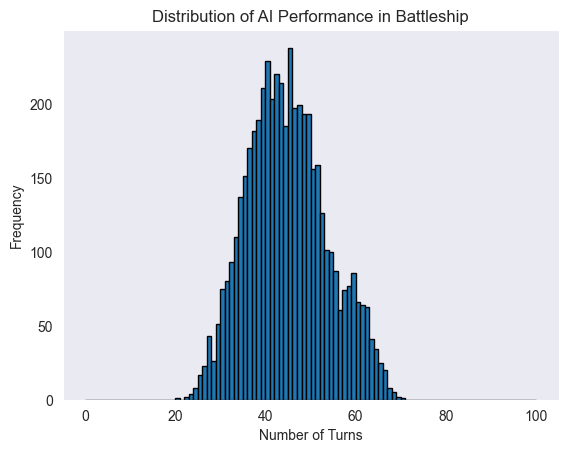

Average number of turns taken by AI to win: 44.385
Median number of turns taken by AI to win: 44.0
Minimum number of turns taken by AI to win: 20
Maximum number of turns taken by AI to win: 70


In [ ]:
#* plot graph of number of turns taken by AI to win over a large number of iterations

import random
import statistics
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

def generate_next_move(board: np.ndarray, ship_sunk_state: list[bool], return_heat_map: bool = False) -> tuple[int, int, any]:

    #* bool test_mode is used to determine whether to return heat map to display using decorator

    heat_map = np.array([[0] * 10 for _ in range(10)])

    # generate heat map based on all possible ship placements
    if 'X' not in board:
        for ship_size, sunk in zip([5, 4, 3, 3, 2], ship_sunk_state):

            # check if ship is already sunk
            if sunk:
                continue

            # place horizontally
            for i in range(10):
                for j in range(10 - ship_size + 1):

                    # skip if ship placement is not possible
                    if set(board[i, j:j + ship_size].ravel()) != {' '}:
                        continue

                    heat_map[i, j:j + ship_size] += 1

            # place vertically
            for i in range(10 - ship_size + 1):
                for j in range(10):

                    # skip if ship placement is not possible
                    if set(board[i:i + ship_size, j].ravel()) != {' '}:
                        continue
                    
                    heat_map[i:i + ship_size, j] += 1

    else:
        
        # target around hit locations
        for ship_size, sunk in zip([5, 4, 3, 3, 2], ship_sunk_state):

            # check if ship is already sunk
            if sunk:
                continue

            #* for each direction, check if ship can be placed. Prioritise a direction if there are multiple hits in a line in the same direction
            #*
            #* i.e.
            #* [ ,  ,  , ]
            #* [ , X, X, ]  --->    Horizontal search will be prioritised since there are multiple hits in a horizontal line
            #* [ ,  ,  , ]
            #*
            #* priority will be determined by number of hits for a possible ship placement by the following values:
            #*
            #*  hits | heat map value
            #* ------|----------------
            #*    1  |      1
            #*    2  |     10
            #*    3  |     20
            #*    4  |     30

            priority_values = [0, 1, 10, 20, 30]
                      
            # check all possible horizontal placements if it coincides with hit locations
            for i in range(10):
                for j in range(10 - ship_size + 1):

                    # skip if ship placement is not possible or does not coincide with hit locations
                    if set(board[i, j:j + ship_size].ravel()) != {' ', 'X'}:
                        continue

                    heat_map[i, j:j + ship_size][board[i, j:j + ship_size] == ' '] += priority_values[np.count_nonzero(board[i, j:j + ship_size] == 'X')]

            # check all possible vertical placements if it coincides with hit locations
            for i in range(10 - ship_size + 1):
                for j in range(10):

                    # skip if ship placement is not possible or does not coincide with hit locations
                    if set(board[i:i + ship_size, j].ravel()) != {' ', 'X'}:
                        continue

                    heat_map[i:i + ship_size, j][board[i:i + ship_size, j] == ' '] += priority_values[np.count_nonzero(board[i:i + ship_size, j] == 'X')]
                    
    # return position with highest heat map value
    if return_heat_map:
        return np.unravel_index(heat_map.argmax(), heat_map.shape) + (heat_map, )
    
    return np.unravel_index(heat_map.argmax(), heat_map.shape)

class Ship:
    def __init__(self, size: int) -> None:
        self.size: int = size
        self.position_unhit: set[tuple[int, int]] = set()
        self.position_hit: set[tuple[int, int]] = set()

        self.hits: int = 0
        self.sunk: bool = False

    def place(self, positions: list[tuple[int, int]]) -> None:
        self.position_unhit = set(positions)

    def register_hit(self, position: tuple[int, int]) -> bool:
        # return True if hit, False if miss
        
        if position not in self.position_unhit:
            return False

        self.position_unhit.remove(position)
        self.position_hit.add(position)
        self.hits += 1
        if self.hits == self.size:
            self.sunk = True
        return True    

class Board:
    def __init__(self) -> None:
        self.grid: np.ndarray = np.array([[' '] * 10 for _ in range(10)])
        self.ships: list[Ship] = [Ship(size) for size in [5, 4, 3, 3, 2]]

        self.turns: int = 0
        
    def print_board(self) -> None:
        print("  " + " ".join(str(i) for i in range(10)))
        for i in range(10):
            print(f"{i} " + " ".join(self.grid[i]))

    def set_ships(self, *positions: list[list[tuple[int, int]]]) -> None:
        # If positions are provided, set ships to the positions
        if positions != ():
            for ship, pos in zip(self.ships, positions):
                ship.place(pos)
            return 
        
        # randomise ship placement if no positions provided
        all_positions = set()

        for ship in self.ships:
            while True:

                orientation = random.choice(['horizontal', 'vertical'])
                if orientation == 'horizontal':
                    row = random.randint(0, 9)
                    col = random.randint(0, 10 - ship.size)
                    ship.position_unhit = {(row, col + i) for i in range(ship.size)}
                else:
                    row = random.randint(0, 10 - ship.size)
                    col = random.randint(0, 9)
                    ship.position_unhit = {(row + i, col) for i in range(ship.size)}
                
                # Check for overlap
                if not all_positions.intersection(ship.position_unhit):
                    all_positions.update(ship.position_unhit)
                    break

    def receive_attack(self, position: tuple[int, int]) -> None:
        for ship in self.ships: 
            if ship.register_hit(position):
                self.grid[position[0], position[1]] = 'X'  # Mark hit

                # Check if the ship is sunk
                if ship.sunk:
                    for i, j in ship.position_hit:
                        self.grid[i, j] = 'S'  # Mark sunk
                return 
            
        self.grid[position[0], position[1]] = 'O'  # Mark miss
        return


    def play_ai_0p(self):
        self.set_ships()

        while True:
            row, col = generate_next_move(self.grid, [ship.sunk for ship in self.ships])
            # time.sleep(0.5)

            self.receive_attack((row, col))
            self.turns += 1
            
            if all(ship.sunk for ship in self.ships):
                break

# plot graph of number of turns taken by AI to win over 5000 iterations

turns_data = []
for i in range(5000):
    print(f"Game {i + 1}/5000")
    board = Board()
    board.play_ai_0p()
    turns_data.append(board.turns)
    clear_output(wait=True)

plt.hist(turns_data, bins=range(0, 101), edgecolor='black')
plt.xlabel('Number of Turns')
plt.ylabel('Frequency')
plt.title('Distribution of AI Performance in Battleship')
plt.show()

print(f"Average number of turns taken by AI to win: {sum(turns_data) / len(turns_data)}")
print(f"Median number of turns taken by AI to win: {statistics.median(turns_data)}")
print(f"Minimum number of turns taken by AI to win: {min(turns_data)}")
print(f"Maximum number of turns taken by AI to win: {max(turns_data)}")